In [27]:
using FFTW
using Interpolations

Ω_points = 2π .* [0.0, 0.277, 0.556, 0.833, 1.0, 1.0, 0.833, 0.556, 0.277, 0.0]
Δ_points = 2π .* [4.08, 3.06, 2.04, 1.02, 0.408, 0.408, 1.02, 2.04, 3.06, 4.08] #MHz I think

T = 1.2
Ω_max = 2.5
ts = range(0, T, length(Ω_points))
Δ(t) = cubic_spline_interpolation(ts, Δ_points)(t) # this could also be `Δ = cubic_spline_interpolation(ts, Δ_points)` ¯\_(ツ)_/¯
Ω(t) = Ω_max * cubic_spline_interpolation(ts, Ω_points)(t)

times = range(0, T, 100)
Ω_fft = fft(Ω.(times))


100-element Vector{ComplexF64}:
   929.2364410787218 + 0.0im
 -361.45953602333344 - 11.359323542975535im
  -34.46010851684524 - 2.1680462608619817im
 -19.370430667439365 - 1.8310448000017372im
  -13.90864262542727 - 1.7570701778992768im
  -8.436394261583148 - 1.336193583477987im
  -5.235900452045017 - 0.9988014290283986im
 -3.8755105858658614 - 0.8662792506892636im
 -3.0516069849565497 - 0.7835195027301753im
 -2.3494105346931153 - 0.6825668578172479im
                     ⋮
  -2.349410534693121 + 0.682566857817246im
  -3.051606984956549 + 0.7835195027301761im
  -3.875510585865861 + 0.8662792506892647im
  -5.235900452045017 + 0.9988014290283989im
  -8.436394261583148 + 1.336193583477987im
  -13.90864262542727 + 1.7570701778992763im
 -19.370430667439365 + 1.8310448000017376im
  -34.46010851684524 + 2.168046260861983im
  -361.4595360233335 + 11.35932354297552im

In [ ]:
using CairoMakie

fig = Figure(size=(1000, 400))
ax_pulse = Axis(fig[1,1])
ax_fft = Axis(fig[1,2])

scatter!(ax_pulse, ts, Ω_points, marker=:star5)
scatter!(ax_pulse, ts, Δ_points, marker=:star5)

lines!(ax_Ω, Ω_fft)

display(fig)

ComputePipeline.ResolveException{MethodError}: Failed to resolve arg1:
[ComputeEdge] arg1 = compute_identity((points, ), changed, cached)
  @ /home/trlarkin/.julia/packages/ComputePipeline/E2l50/src/ComputePipeline.jl:743
[ComputeEdge] points, grouplengths = (::MapFunctionWrapper(#plot!##146))((values, edges, normalization, scale_to, weights, groups, ), changed, cached)
  @ unknown method location
[ComputeEdge] edges = (::MapFunctionWrapper(pick_hist_edges))((values, bins, ), changed, cached)
  @ unknown method location
  with edge inputs:
    values = ComplexF64[929.2364410787218 + 0.0im, -361.45953602333344 - 11.359323542975535im, -34.46010851684524 - 2.1680462608619817im, -19.370430667439365 - 1.8310448000017372im, -13.90864262542727 - 1.7570701778992768im, -8.436394261583148 - 1.336193583477987im, -5.235900452045017 - 0.9988014290283986im, -3.8755105858658614 - 0.8662792506892636im, -3.0516069849565497 - 0.7835195027301753im, -2.3494105346931153 - 0.6825668578172479im  …  -1.891716

Run the IBA gate in the full 9-level system
---------------------------------
Use the same $\Omega(t), \Delta(t)$ pulse shape (same `T`, `Ω_max`) analyzed above, but now actually propagate it through the full 9-level two-atom Rydberg model (`iba_Hamiltonian` from `RydbergUtils`) to see the resulting gate fidelity.

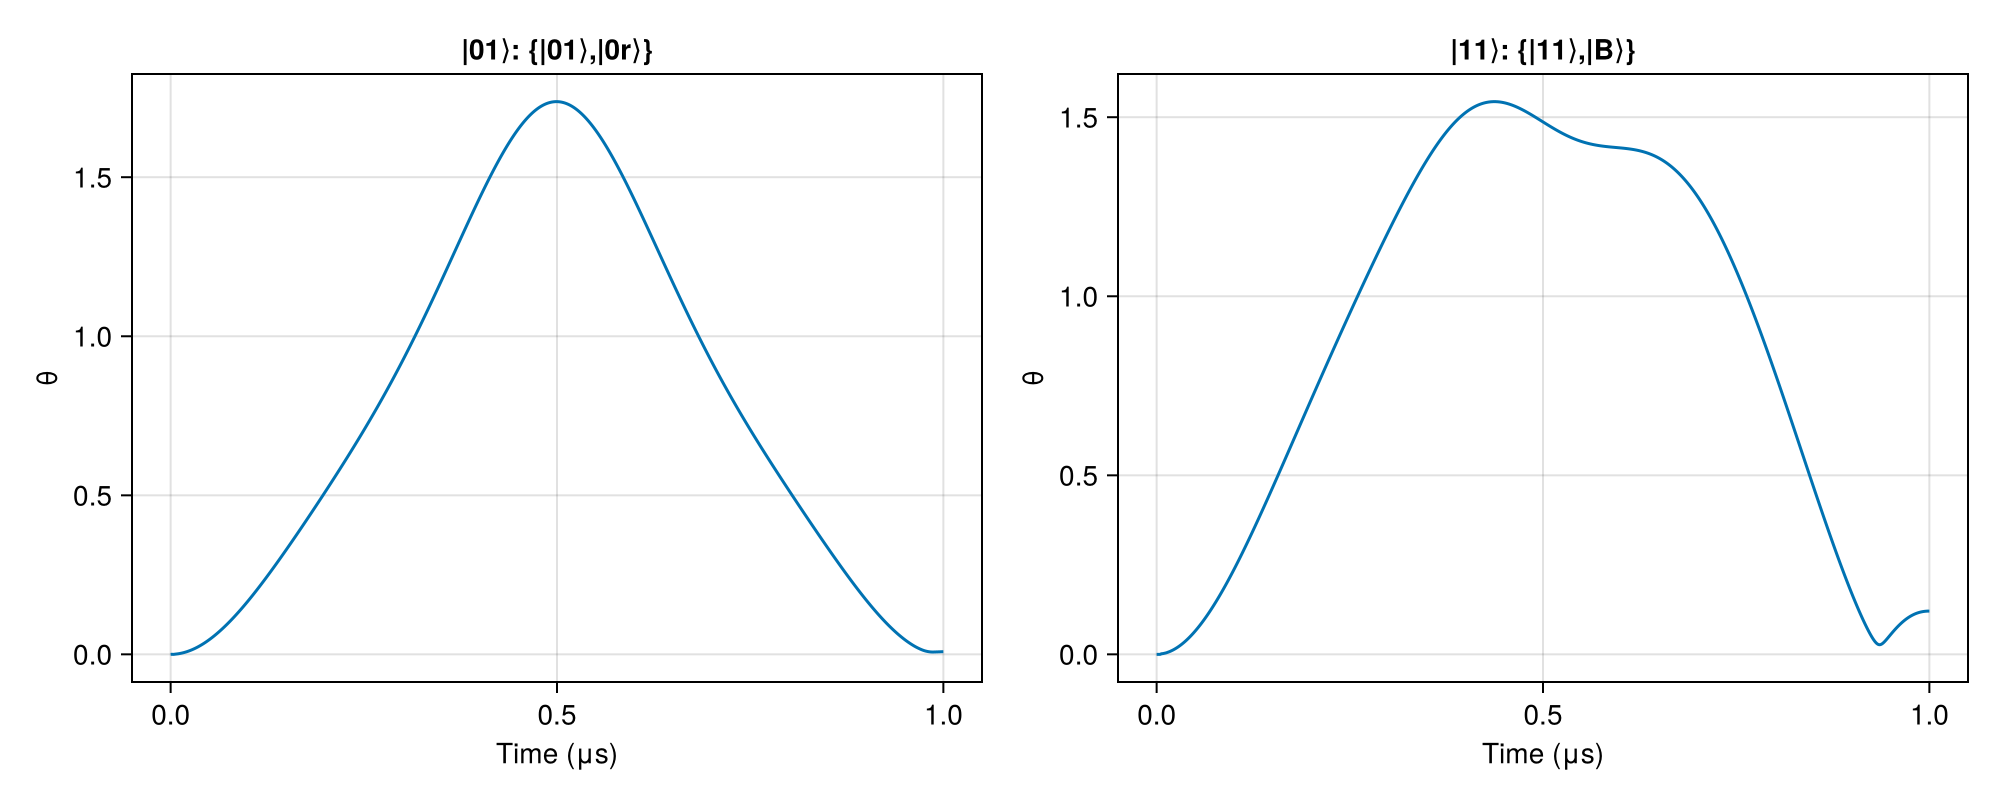

CairoMakie.Screen{IMAGE}


In [5]:
using QuantumOptics
using RydbergUtils
using FFTW
using CairoMakie

ibaH = iba_Hamiltonian(T=1.0, Vrr=500)
CZ = CompositeHamiltonianTL([ibaH])
T_CZ = totalTime(CZ)

# Basis index = (atom2_level-1)*3 + atom1_level, levels 1,2,3 = |0>,|1>,|r>.
# |0,1> only ever mixes with |0,r> (idx 4, 7): atom 1 sits in |0>, which the laser
# never couples to (rydbergLaser only drives |1><->|r>), so this is an EXACT 2-level subspace.
project01(ψ) = Ket(SpinBasis(1//2), [ψ[4], ψ[7]])

# |1,1> (idx 5) stays in the fully-symmetric sector {|11>, (|1r>+|r1>)/√2, |rr>} because the
# Hamiltonian and the input are both exchange-symmetric. Projecting onto {|11>, B} (idx 5 and
# the symmetric combination of idx 6, 8) drops |rr>, so r < 1 exactly when population leaks
# into |rr> -- i.e. whenever the finite Vrr blockade isn't perfect. That's a real diagnostic,
# not an approximation artifact.
projectB(ψ) = Ket(SpinBasis(1//2), [ψ[5], (ψ[6] + ψ[8])/√2])

path01 = schroedingerTimeEvolve(s01, CZ, reportedTimes=1000)
θ_01 = getindex.(statevectorToBlochvectorθϕr.(project01.(path01)), 1)

path11 = schroedingerTimeEvolve(s11, CZ, reportedTimes=1000)
θ_11 = getindex.(statevectorToBlochvectorθϕr.(projectB.(path11)), 1)

# fft(θ_01)


fig = Figure(size=(1000, 400))
ax_01 = Axis(fig[1,1], xlabel="Time (μs)", ylabel="θ", title="|01⟩: {|01⟩,|0r⟩}")
ax_11 = Axis(fig[1,2], xlabel="Time (μs)", ylabel="θ", title="|11⟩: {|11⟩,|B⟩}")

lines!(ax_01, range(0, T_CZ, length(θ_01)), θ_01)
lines!(ax_11, range(0, T_CZ, length(θ_11)), θ_11)

display(fig)

FFT of the θ trajectories, reconstructed as a sum of cosines
---------------------------------
Take the FFT of $\theta_{01}(t)$ and $\theta_{11}(t)$ above, then rebuild each signal explicitly as $\sum_k A_k \cos(\omega_k t + \phi_k)$ using the amplitude/phase found by the FFT at every frequency bin, and overlay it on the original curve. Since this keeps *all* frequency components it's a lossless synthesis (mathematically the same as `ifft`) — a sanity check that the FFT decomposition is being read out correctly before using it for anything (e.g. truncating to the dominant harmonics).

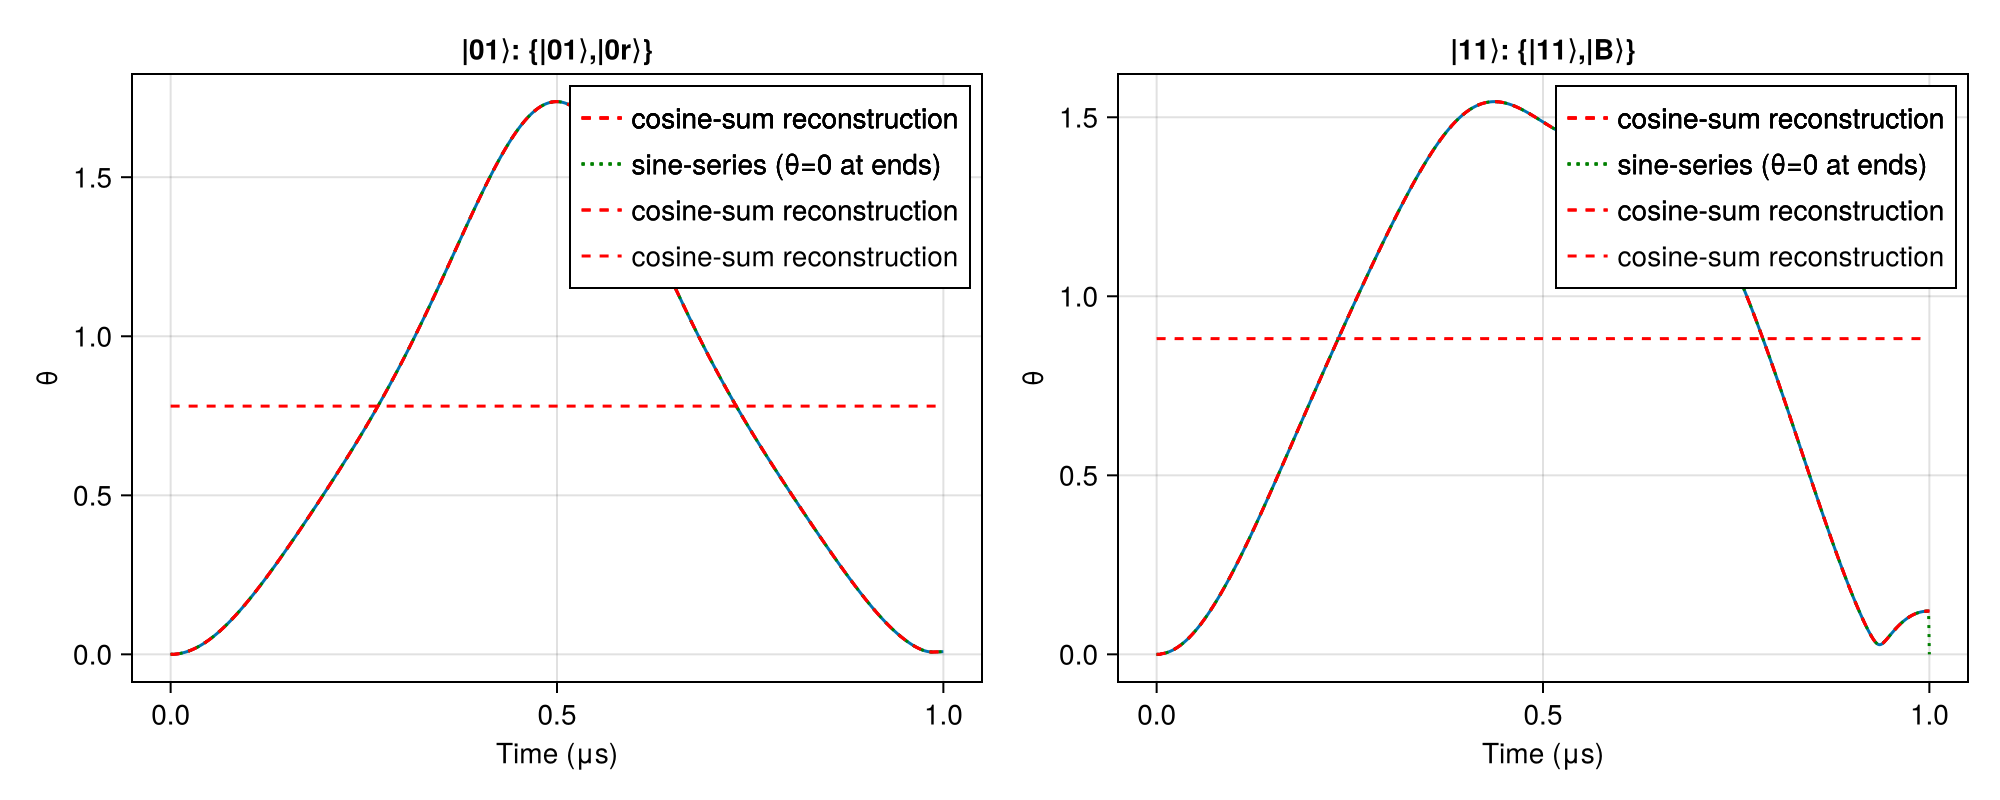

CairoMakie.Screen{IMAGE}


In [9]:
function cosine_series(x::AbstractVector{<:Real})
    N = length(x)
    X = fft(x)
    n = 0:N-1
    y = fill(real(X[1]) / N, N)  # DC term
    for k in 1:(N ÷ 2)
        Xk = X[k+1]
        if iseven(N) && k == N ÷ 2  # unpaired Nyquist term
            y .+= 0
            # y .+= (real(Xk)/N) .* cos.(π .* n)
        else
            # y .+= 0
            y .+= (2*abs(Xk)/N) .* cos.(2π*k .* n ./ N .+ angle(Xk))
        end
    end
    return y
end

θ_01_fft = fft(θ_01)
θ_11_fft = fft(θ_11)

θ_01_recon = cosine_series(θ_01)
θ_11_recon = cosine_series(θ_11)

times_θ = range(0, T_CZ, length(θ_01))

lines!(ax_01, times_θ, θ_01_recon, color=:red, linestyle=:dash, label="cosine-sum reconstruction")
lines!(ax_11, times_θ, θ_11_recon, color=:red, linestyle=:dash, label="cosine-sum reconstruction")
axislegend(ax_01)
axislegend(ax_11)

display(fig)

Zero-endpoint approximation: sine series
---------------------------------
A plain cosine series can't force $\theta(0)=\theta(T)=0$ (every $\cos(k\pi t/T)$ equals 1 at $t=0$). What does is a **sine** series: $\sin(k\pi t/T)$ is exactly 0 at both $t=0$ and $t=T$ for every integer $k$, so any weighted sum of them is too. Note both $\theta_{01}$ and $\theta_{11}$ actually end at a small but nonzero value ($\theta(T)\neq 0$) — some residual population is left away from the qubit states after the second UV pulse — so this sine-series fit is a genuine (lossy) approximation: it reproduces the interior of the trajectory essentially exactly, but forces the endpoint down to 0 by construction, visibly departing from the raw curve right at $t=T$.

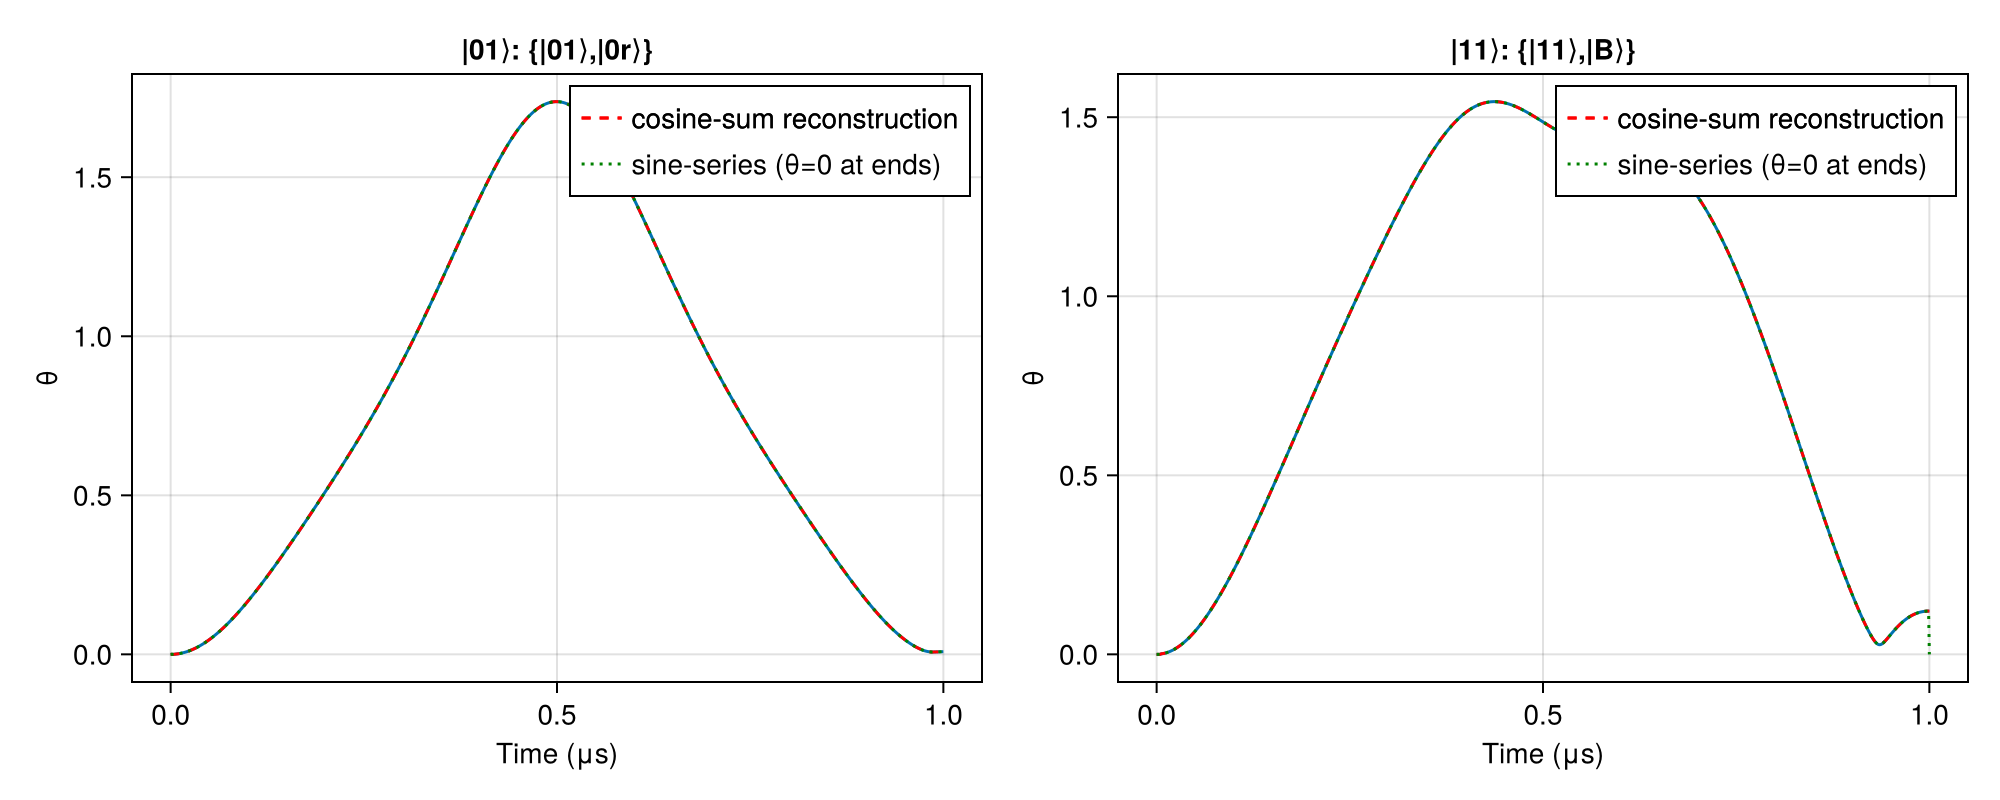

CairoMakie.Screen{IMAGE}


In [7]:
"""
Sine-series (Dirichlet, θ(0)=θ(T)=0) decomposition of x. Treats x[1], x[end] as the
fixed zero boundary values and expands the interior in sin(kπn/(N+1)), which is
exactly zero at n=0 and n=N+1 for every k -- so the reconstruction is pinned to
zero at both ends regardless of what x[1], x[end] actually were.
"""
function sine_series(x::AbstractVector{<:Real})
    interior = x[2:end-1]
    N = length(interior)
    n = 1:N
    S = [sin(k*π*ni/(N+1)) for ni in n, k in 1:N]  # N×N sine basis matrix
    b = (2/(N+1)) .* (S' * interior)                # coefficients
    y_interior = S * b                              # reconstruction
    return [0.0; y_interior; 0.0]
end

θ_01_sine = sine_series(θ_01)
θ_11_sine = sine_series(θ_11)

lines!(ax_01, times_θ, θ_01_sine, color=:green, linestyle=:dot, label="sine-series (θ=0 at ends)")
lines!(ax_11, times_θ, θ_11_sine, color=:green, linestyle=:dot, label="sine-series (θ=0 at ends)")
axislegend(ax_01)
axislegend(ax_11)

display(fig)